# 01 · Inspect the CWRU vibration recordings

**Rifat's bearing fault diagnosis thesis · First practical milestone**

## Goal
Open the four downloaded MATLAB files, identify the drive-end signal, and plot the recorded values. By the end, you should be able to explain what one file, one sensor sample, and one signal array represent.

**Run one code cell at a time with Shift+Enter.** Select your **Python (Bearing Thesis)** kernel or the project's `.venv/bin/python` in VS Code. Save this notebook under the project's `notebooks` folder.

This notebook was prepared from your reported download status. Your `.mat` files are on your laptop, so the notebook is delivered **without executed data outputs**. All tables and waveforms below are computed from those files when you run it; no example waveforms are substituted.

## Setup

Think of a recording as a long audio track: it holds an ordered sequence of measurements. A sensor sample is one reading; a future model input will contain many consecutive readings. Splitting a recording into clips does not create new independent bearings.

Your reported drive-end sample counts were:

| File | Condition | Sensor readings |
|---|---|---:|
| 97.mat | Normal | 243,938 |
| 105.mat | Inner-race fault | 121,265 |
| 118.mat | Ball fault | 122,571 |
| 130.mat | Outer-race fault (@6) | 121,991 |

These are **reported counts to compare against**, not outputs already computed in this notebook. The selected fault recordings come from the official 12 kHz, 0 HP, 0.007-inch subset; the normal file comes from the normal baseline table. The normal channel's sampling rate remains unconfirmed in this notebook. Its longer array alone does not establish recording duration or sampling rate.

We will plot against **sample number**, and retain amplitude **as stored** until physical units and sampling metadata are documented. Equal numbers of samples need not cover equal durations. Today's plots are exploratory and cannot establish generalization or prove a model can distinguish unseen bearings.

### 1. Import the tools

- `Path` builds file paths.
- `loadmat` opens a MATLAB file as a Python dictionary.
- NumPy works with signal arrays; pandas builds inspection tables.
- Matplotlib draws waveforms.

If an import fails, run `python -m pip install numpy scipy pandas matplotlib ipykernel` in your activated project terminal, then restart the notebook kernel.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
from IPython.display import display

print('Python:', sys.version.split()[0])
print('Interpreter:', sys.executable)

plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
})

Python: 3.12.13
Interpreter: /run/media/rifat-hasan/Felicitous/bearing-fault-cnn-lstm/.venv/bin/python


### 2. Locate the data

The absolute project path makes this work whether the notebook starts from the project root or its `notebooks` folder. The `/` operator joins path components when used with a `Path` object.

In [2]:
PROJECT_ROOT = Path('/run/media/rifat-hasan/Felicitous/bearing-fault-cnn-lstm')
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'

recordings = {
    '97.mat': 'Normal',
    '105.mat': 'Inner-race fault',
    '118.mat': 'Ball fault',
    '130.mat': 'Outer-race fault (@6)',
}

reported_counts = {
    '97.mat': 243938,
    '105.mat': 121265,
    '118.mat': 122571,
    '130.mat': 121991,
}

missing = [name for name in recordings if not (RAW_DIR / name).is_file()]
if missing:
    raise FileNotFoundError(f'Missing from {RAW_DIR}: {missing}')

print('Data folder:', RAW_DIR)
print('All four expected files are present.')

Data folder: /run/media/rifat-hasan/Felicitous/bearing-fault-cnn-lstm/data/raw
All four expected files are present.


## Steps

### 3. Look inside one recording

Start with `97.mat`. A MATLAB file can contain several named variables, rather than a single spreadsheet-like table. `normal_mat` is a dictionary: a variable name is a key, and its contents are the value.

The CWRU documentation defines `DE` as the drive-end accelerometer, `FE` as the fan-end accelerometer, and `RPM` as rotational speed. The suffix `time` identifies time-series data; it does **not** mean the array is a list of timestamps.

In [3]:
normal_mat = loadmat(RAW_DIR / '97.mat')

print('Python object:', type(normal_mat))
print('Variable names:', list(normal_mat.keys()))

variables = []
for name, value in normal_mat.items():
    if not name.startswith('__'):
        array = np.asarray(value)
        variables.append({
            'variable': name,
            'shape': str(array.shape),
            'dtype': str(array.dtype),
        })

display(pd.DataFrame(variables))

Python object: <class 'dict'>
Variable names: ['__header__', '__version__', '__globals__', 'X097_DE_time', 'X097_FE_time', 'X097RPM']


,variable,shape,dtype
0,X097_DE_time,"(243938, 1)",float64
1,X097_FE_time,"(243938, 1)",float64
2,X097RPM,"(1, 1)",uint16


### 4. Extract the drive-end signal

We find the key by its `_DE_time` suffix instead of assuming every file uses the same numeric prefix.

A shape such as `(243938, 1)` means **243,938 rows and one column**. Converting it to `(243938,)` gives a one-dimensional signal. The comma in `(243938,)` is Python's notation for a one-item tuple. `reshape(-1)` puts the existing values into one dimension; it does not resample, normalize, or reorder this single-column signal.

In [4]:
de_keys = [name for name in normal_mat if name.endswith('_DE_time')]
if len(de_keys) != 1:
    raise ValueError(f'Expected one drive-end variable; found {de_keys}')

normal_key = de_keys[0]
normal_array = np.asarray(normal_mat[normal_key])
if normal_array.ndim != 2 or 1 not in normal_array.shape:
    raise ValueError(f'Inspect unexpected signal shape: {normal_array.shape}')

normal_signal = normal_array.reshape(-1)

print('Selected variable:', normal_key)
print('Original shape:', normal_array.shape)
print('One-dimensional shape:', normal_signal.shape)
print('Sensor readings:', normal_signal.size)

display(pd.DataFrame({
    'sample_number': np.arange(10),
    'recorded_amplitude': normal_signal[:10],
}))

Selected variable: X097_DE_time
Original shape: (243938, 1)
One-dimensional shape: (243938,)
Sensor readings: 243938


,sample_number,recorded_amplitude
0,0,0.053197
1,1,0.088662
2,2,0.099718
3,3,0.058621
4,4,-0.004590
5,5,-0.056952
6,6,-0.071764
7,7,-0.058621
8,8,-0.046521
9,9,-0.049859


### 5. Draw your first waveform

The horizontal axis is the sensor-sample index, starting at zero. The vertical axis is the recorded amplitude. Joining neighboring points makes the ordered variation visible.

We show 2,048 consecutive readings to keep the plot readable. This is a **plotting choice**, not a finalized model window size. Change `START_SAMPLE` to inspect another portion without modifying the original data.

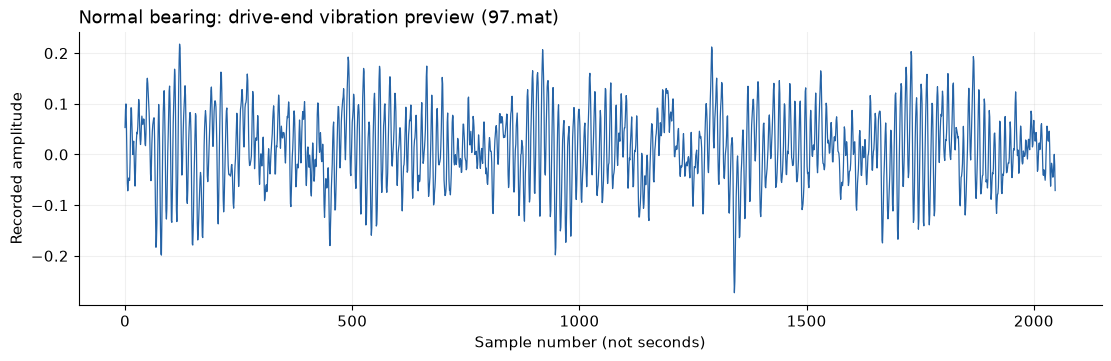

In [5]:
START_SAMPLE = 0
N_DISPLAY = 2048

if START_SAMPLE < 0 or N_DISPLAY < 2:
    raise ValueError('Choose START_SAMPLE >= 0 and N_DISPLAY >= 2.')
if START_SAMPLE + N_DISPLAY > normal_signal.size:
    raise ValueError('The requested preview extends beyond the recording.')

sample_numbers = np.arange(START_SAMPLE, START_SAMPLE + N_DISPLAY)
normal_preview = normal_signal[START_SAMPLE:START_SAMPLE + N_DISPLAY]

fig, ax = plt.subplots(figsize=(11, 3.5), layout='constrained')
ax.plot(sample_numbers, normal_preview, color='#2563A6', linewidth=0.9)
ax.set_title('Normal bearing: drive-end vibration preview (97.mat)', loc='left')
ax.set_xlabel('Sample number (not seconds)')
ax.set_ylabel('Recorded amplitude')
ax.grid(alpha=0.18)
plt.show()

### 6. Load all four signals and build the inventory

Now repeat the same loading process. `signals` is a dictionary containing one one-dimensional array per file. We keep these recordings separate.

The inventory measures the actual array lengths and counts missing (`NaN`) or infinite values. `sampling_rate_hz` is documented metadata, not inferred from array size: the fault recordings are 12 kHz, and the normal value is left unknown. Passing these checks does not authenticate the downloads against an official checksum or establish independent test bearings.

In [6]:
signals = {}
inventory_rows = []
sampling_rates = {'97.mat': None, '105.mat': 12000, '118.mat': 12000, '130.mat': 12000}

for file_name, condition in recordings.items():
    contents = loadmat(RAW_DIR / file_name)
    keys = [name for name in contents if name.endswith('_DE_time')]
    if len(keys) != 1:
        raise ValueError(f'{file_name}: expected one drive-end variable, found {keys}')

    original = np.asarray(contents[keys[0]])
    if original.ndim != 2 or 1 not in original.shape:
        raise ValueError(f'{file_name}: unexpected shape {original.shape}')
    if not np.issubdtype(original.dtype, np.number) or np.iscomplexobj(original):
        raise ValueError(f'{file_name}: expected a real numeric signal')

    signal = original.reshape(-1)
    if signal.size == 0:
        raise ValueError(f'{file_name}: empty drive-end signal')

    signals[file_name] = signal
    inventory_rows.append({
        'file': file_name,
        'condition': condition,
        'signal_key': keys[0],
        'sensor_samples': signal.size,
        'sampling_rate_hz': sampling_rates[file_name],
        'nan_count': int(np.isnan(signal).sum()),
        'infinite_count': int(np.isinf(signal).sum()),
        'matches_reported_count': signal.size == reported_counts[file_name],
    })

inventory = pd.DataFrame(inventory_rows)
inventory['sampling_rate_hz'] = inventory['sampling_rate_hz'].astype('Int64')
display(inventory)

if inventory[['nan_count', 'infinite_count']].to_numpy().sum() != 0:
    raise ValueError('Non-finite values found. Investigate before continuing.')
if not inventory['matches_reported_count'].all():
    raise ValueError('A sample count differs from your reported download status. Check the file before continuing.')

print('All four signals are finite and match your reported sample counts.')

,file,condition,signal_key,sensor_samples,sampling_rate_hz,nan_count,infinite_count,matches_reported_count
0,97.mat,Normal,X097_DE_time,243938,<NA>,0,0,True
1,105.mat,Inner-race fault,X105_DE_time,121265,12000,0,0,True
2,118.mat,Ball fault,X118_DE_time,122571,12000,0,0,True
3,130.mat,Outer-race fault (@6),X130_DE_time,121991,12000,0,0,True


All four signals are finite and match your reported sample counts.


### 7. Compare the waveforms

Each panel shows the same sample-index span. **All four panels share the same vertical scale**, so automatic scaling cannot make a small-amplitude signal look as large as a high-amplitude signal. The earlier normal-only plot lets you examine its finer structure.

The four panels do not yet establish equal durations or frequency content. Use them to ask questions about the recordings, rather than conclude that a visible pattern universally identifies a fault.

Here, `axes` is a one-dimensional array of four plotting areas. `enumerate` gives us each file's position (`i`), and `axes[i]` selects the corresponding panel. This is the same idea as choosing a subplot with `ax.flat[i]` when the plotting areas form a two-dimensional grid.

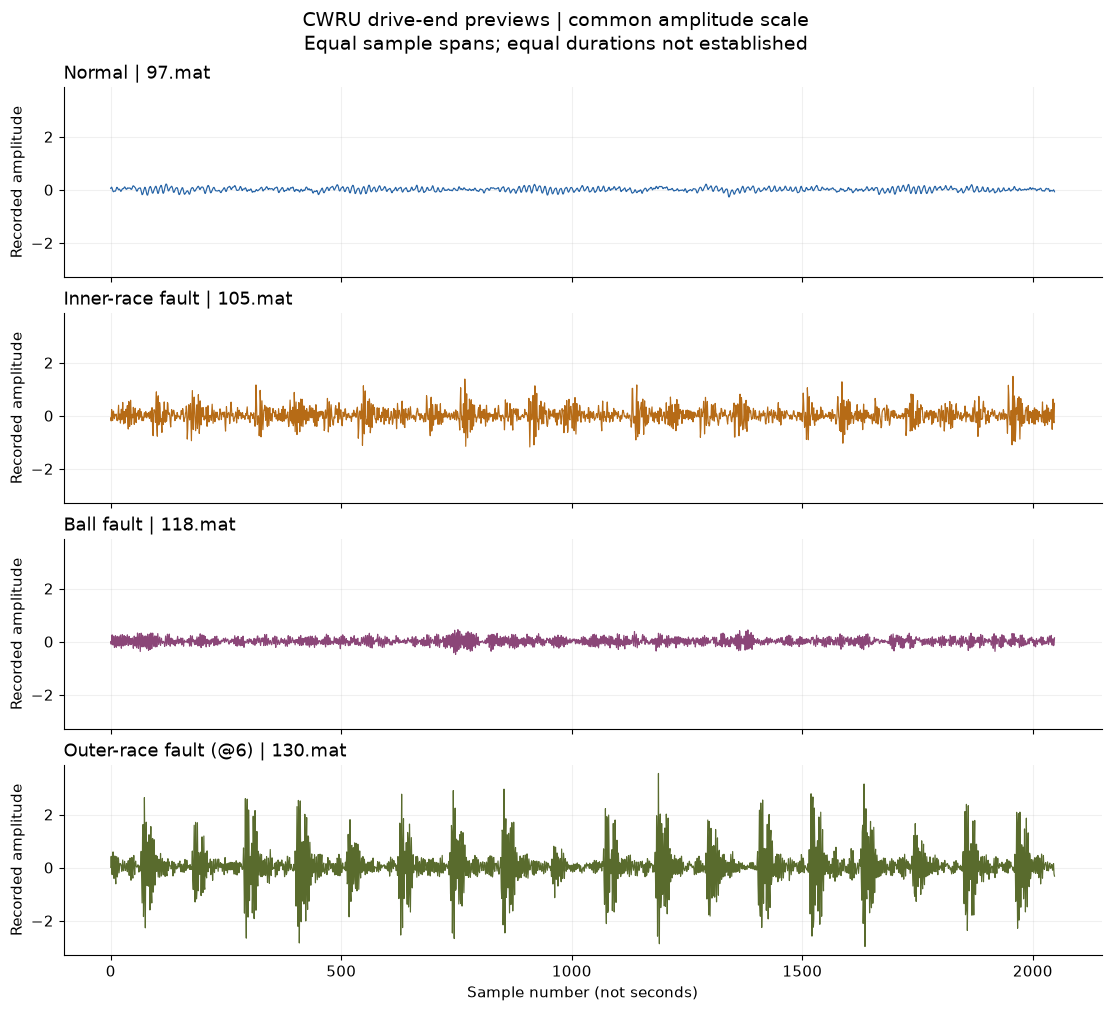

In [7]:
colors = ['#2563A6', '#B66B16', '#8B4678', '#596B2D']

for file_name, signal in signals.items():
    if START_SAMPLE + N_DISPLAY > signal.size:
        raise ValueError(f'{file_name}: choose a shorter or earlier preview.')

comparison_fig, axes = plt.subplots(
    4, 1, figsize=(11, 10), sharex=True, sharey=True, layout='constrained'
)

for i, (file_name, condition) in enumerate(recordings.items()):
    preview = signals[file_name][START_SAMPLE:START_SAMPLE + N_DISPLAY]
    ax = axes[i]
    ax.plot(sample_numbers, preview, color=colors[i], linewidth=0.85)
    ax.set_title(f'{condition} | {file_name}', loc='left')
    ax.set_ylabel('Recorded amplitude')
    ax.grid(alpha=0.18)

axes[-1].set_xlabel('Sample number (not seconds)')
comparison_fig.suptitle(
    'CWRU drive-end previews | common amplitude scale\n'
    'Equal sample spans; equal durations not established',
    fontsize=14,
)
plt.show()

### 8. Save the inventory and figure

These are useful artifacts for your supervisor update. This cell writes the inventory and the comparison figure under `reports`; rerunning it updates those two outputs. The raw `.mat` files are not changed.

In [8]:
REPORT_DIR = PROJECT_ROOT / 'reports'
FIGURE_DIR = REPORT_DIR / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

inventory_path = REPORT_DIR / '01_recording_inventory.csv'
figure_path = FIGURE_DIR / '01_drive_end_previews.png'

inventory.to_csv(inventory_path, index=False)
comparison_fig.savefig(figure_path, dpi=180, bbox_inches='tight')

print('Saved inventory:', inventory_path)
print('Saved figure:', figure_path)

Saved inventory: /run/media/rifat-hasan/Felicitous/bearing-fault-cnn-lstm/reports/01_recording_inventory.csv
Saved figure: /run/media/rifat-hasan/Felicitous/bearing-fault-cnn-lstm/reports/figures/01_drive_end_previews.png


## Checks

Before moving on, confirm:

- The interpreter belongs to `bearing-fault-cnn-lstm/.venv`.
- The four measured counts match your download log.
- All `nan_count` and `infinite_count` values are zero.
- You can explain the difference between a variable name, its NumPy array, and one reading in that array.
- You can explain why the x-axis says sample number rather than seconds.

Write two observations based on your **actual plots**. An observation is something you see; an explanation is a hypothesis to investigate. Avoid asserting that all defective bearings must have larger amplitudes, or that 2,048 readings are independent examples.

**Observation 1:** ...

**Observation 2:** ...

**One question to investigate next:** ...

## Next Steps

Share the inventory and comparison figure, along with any confusing cell. We will confirm sampling metadata and units, inventory additional recordings, and then define a split before windowing and normalization. We need more than one recording per class for a recording-separated, four-class train/test experiment.

For today, the milestone is successful loading and inspection, not training accuracy. The notebook does not split, normalize, resample, or train a model.

### References

- [CWRU file format and variable naming](https://engineering.case.edu/bearingdatacenter/download-data-file)
- [CWRU 12 kHz drive-end fault table](https://engineering.case.edu/bearingdatacenter/12k-drive-end-bearing-fault-data)
- [CWRU normal baseline table](https://engineering.case.edu/bearingdatacenter/normal-baseline-data)
- [SciPy loadmat documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.io.loadmat.html)

Source context: CWRU metadata reviewed on 13 September 2026; sample counts supplied by the user. No waveform interpretation is claimed before local execution. Notebook structure and Python syntax can be checked without the recordings; runtime output and plot appearance require the real data and the selected notebook kernel.